In [1]:
from tempfile import TemporaryDirectory

import scarf
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level='WARNING', progress=True)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)

analysis_directory = TemporaryDirectory()
repacked_counts = f'{analysis_directory.name}/counts.zarr'
repack_store(
    f'{dataset}/data.zarr',
    repacked_counts,
    nthreads=2,
)
ds = scarf.mount_datastore(
    repacked_counts,
    at=f'{analysis_directory.name}/analysis.zarr',
    nthreads=4,
    default_assay='RNA'
)
hvg_ref = ds.mark_hvgs(
    top_n=2000,
    show_plot=False,
    label='pseudotime_hvgs',
)
normalized = ds.run_normalization(features=hvg_ref)
reduction = ds.run_pca(normalized, dims=15)
ann_index = ds.build_ann_index(reduction)
neighbors = ds.query_neighbors(ann_index, k=11)
graph = ds.build_connectivity_map(neighbors)
all_features = ds.resolve_features('RNA', 'all_features')

Downloading bucket files: 43423201 / 43423201 complete

Downloading bytes: 43423201 / 43423201 complete

Repacking RNA/artifacts/connectivity_map//edges: 1 / 1 complete

Repacking RNA/artifacts/reduction//loadings: 1 / 1 complete

Repacking RNA/artifacts/reduction//data: 1 / 1 complete

...

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

In [3]:
ds.cells.to_pandas_dataframe(
    ['clusters'],
    key='I'
)['clusters'].value_counts()

clusters
Ductal           916
Ngn3 high EP     642
Pre-endocrine    592
Beta             591
Alpha            481
Ngn3 low EP      262
Epsilon          142
Delta             70
Name: count, dtype: int64

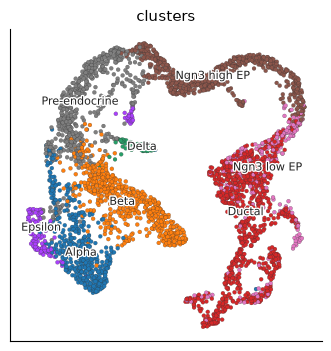

In [4]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='clusters',
    legend_loc='on_data',
)

In [5]:
pseudotime = ds.run_pseudotime_scoring(
    graph,
    source_sink_key='clusters',
    sources=['Ductal'],
    sinks=['Alpha', 'Beta', 'Delta'],
)

In [6]:
{
    "pseudotime_key": pseudotime.pseudotime_key,
    "validity_key": pseudotime.validity_key,
    "valid cells": int(ds.cells.fetch_all(pseudotime.validity_key).sum()),
}

{'pseudotime_key': 'RNA_pseudotime',
 'validity_key': 'RNA_pseudotime__valid',
 'valid cells': 3696}

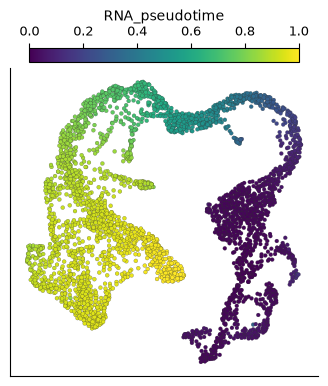

In [7]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=pseudotime.pseudotime_key,
    subset_by=pseudotime.validity_key,
)

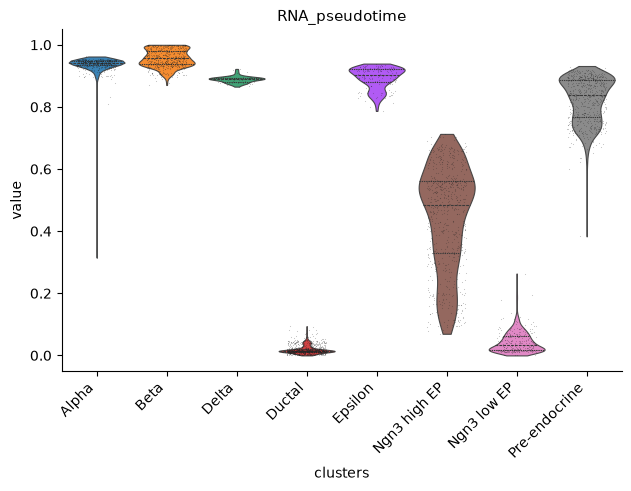

In [8]:
ds.plots.distribution(
    keys=pseudotime.pseudotime_key,
    group_by='clusters',
    subset_by=pseudotime.validity_key,
    kind='violin',
)

In [9]:
markers = ds.run_pseudotime_marker_search(
    features=all_features,
    cell_key=pseudotime.validity_key,
    pseudotime_key=pseudotime.pseudotime_key,
)

Finding correlated features: 2 / 2 complete

In [10]:
markers.table[["p_value", "p_value_adjusted"]].isna().sum()

p_value             14177
p_value_adjusted    14177
dtype: int64

In [11]:
markers.table[["p_value", "p_value_adjusted"]].notna().sum()

p_value             13821
p_value_adjusted    13821
dtype: int64

In [12]:
tested = markers.table.loc[
    markers.table["p_value_adjusted"].notna(),
    ["feature_name", "r_value", "p_value_adjusted"],
]
(
    tested.loc[tested["r_value"] > 0]
    .sort_values("r_value", ascending=False)
    .head(10)
)

,feature_name,r_value,p_value_adjusted
14296,Gnas,0.746690,0.0
23549,Cpe,0.740661,0.0
21244,Aplp1,0.716944,0.0
3186,Fam183b,0.680168,0.0
25060,Hmgn3,0.637203,0.0
26730,Pcsk1n,0.634557,0.0
26573,Bex2,0.622020,0.0
2189,Rap1b,0.612822,0.0
5837,Scgn,0.609830,0.0
26753,Tspan7,0.598690,0.0


In [13]:
(
    tested.loc[tested["r_value"] < 0]
    .sort_values("r_value", ascending=True)
    .head(10)
)

,feature_name,r_value,p_value_adjusted
24581,Rpl13,-0.829222,0.0
22385,Rps19,-0.822204,0.0
18864,Spp1,-0.820563,0.0
16254,Rps8,-0.817266,0.0
19815,Rpl32,-0.794270,0.0
26498,Rps4x,-0.794137,0.0
431,Dbi,-0.787537,0.0
13425,Rpl12,-0.769970,0.0
10164,Rps2,-0.755999,0.0
10232,Rpl10a,-0.754087,0.0


In [14]:
checkpoint_genes = ["Spp1", "Cpe"]
checkpoint = (
    markers.table.set_index("feature_name")
    .loc[checkpoint_genes, ["r_value", "p_value_adjusted"]]
)
checkpoint

,r_value,p_value_adjusted
feature_name,,
Spp1,-0.820563,0.0
Cpe,0.740661,0.0


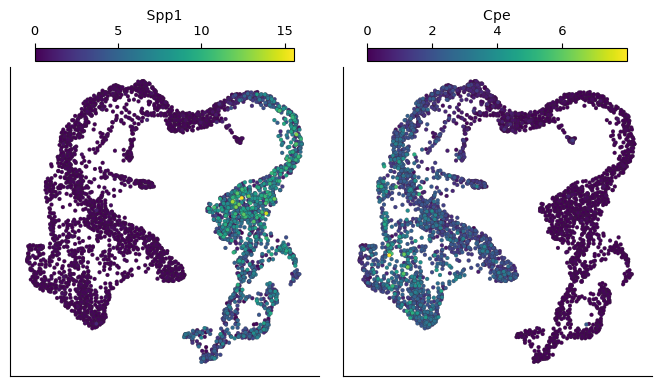

In [15]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=checkpoint_genes,
    n_columns=2,
    sort_values=True,
)

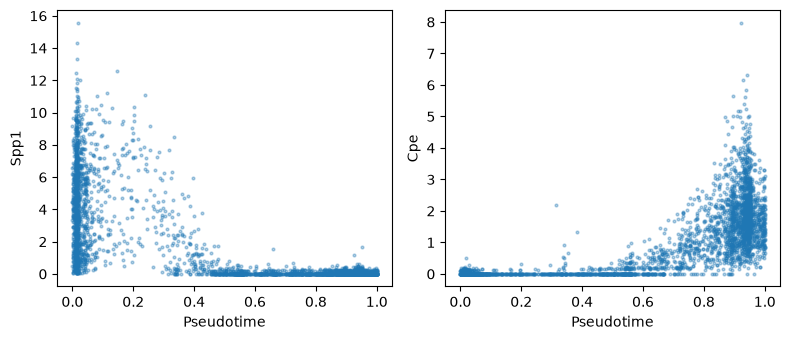

In [16]:
import matplotlib.pyplot as plt

cell_key = pseudotime.validity_key
ptime = ds.get_cell_vals(
    from_assay="RNA",
    cell_key=cell_key,
    k=pseudotime.pseudotime_key,
)
figure, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharex=True)
for axis, gene in zip(axes, checkpoint_genes, strict=True):
    expression = ds.get_cell_vals(
        from_assay="RNA",
        cell_key=cell_key,
        k=gene,
    )
    axis.scatter(ptime, expression, s=4, alpha=0.35)
    axis.set(xlabel="Pseudotime", ylabel=gene)
figure.tight_layout()
plt.show()